# Binarization with scBoolSeq

1) Set the GO per macrostate for the evaluation of the HVG and binarization results 
2) Binarize the matrix, the workflow is based on the raw matrix, and the macrostates are binarized separately
3) Evaluate the binarization result 

In [49]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/cll_bridge_stream.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
macrostates_computed="timepoint" # stream2 or timepoint

In [2]:
import sys
#!pip install gseapy
#!pip install scboolseq
import scanpy as sc
import numpy as np
import pandas as pd
from scboolseq import scBoolSeq
import gc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import gseapy as gp
from gseapy import get_library
from scipy.stats import fisher_exact
import json
import requests
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde
#! pip install goatools
#!pip install leidenalg

In [50]:
warnings.filterwarnings("ignore")
adata = sc.read(input_file) # read data 
if adata.X.max() > 10 : # check if is raw data, need to be > 10
    # Normalization
    sc.pp.normalize_total(adata) # 
    sc.pp.log1p(adata)
    print("=== This dataset is now normalised")
else :
    print("=== This dataset appears to have already been normalised")

# Verify if we have only the cells expected and the macrostates 
print("=== Cell type and macrostates in our dataset")
print(adata.obs["Annotation"].unique())
print(adata.obs["macrostates"].unique())

=== This dataset is now normalised
=== Cell type and macrostates in our dataset
['B naive', 'B intermediate', 'B', 'B memory', 'Bridge']
Categories (5, object): ['B', 'B intermediate', 'B memory', 'B naive', 'Bridge']
['None', 'S9', 'S8', 'S0', 'S5', 'S4', 'S2']
Categories (7, object): ['None', 'S0', 'S2', 'S4', 'S5', 'S8', 'S9']


# 1) Binarization with scBoolSeq

## Binarization macrostates separately on HVG

Majority vote threshold fixed 

In [46]:
#if macrostates_computed=="timepoint":
#    mapping = {0: "I1",1: "I2",2: "T1",3: "T2",4: "T3",5: "None"}
#    adata.obs["macrostates"] = adata.obs["macrostates"].map(mapping)
#    print(adata.obs["macrostates"].unique())

In [25]:
warnings.filterwarnings("ignore")
macrostates = [x for x in adata.obs['node_label'].unique() if x != 'None']
print(macrostates)
binarized_states = {}
all_hvg = set()
adata_ct_dict = {}
hvg_dict = {}

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"  {n_cells} cells")
    
    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)
    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index.tolist()
    hvg_dict[ct] = hvg_genes
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")
    
    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()
    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )
    # Remove all-zero genes
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f" {expr_df_full.shape[1]} genes after removing all-zero")
    
    # STEP 3 : scBoolSeq model
    scbool = scBoolSeq(
        zeroinf_binarizer="quantile",
        margin_quantile=0.2,
        dor_threshold=0.85,
        alpha=0
    )
    scbool.fit(expr_df_full)
    print("  scBoolSeq fitted")
    
    # STEP 4 : Binarization
    binarized = scbool.binarize(expr_df_full)
    
    # STEP 5 : Majority vote
    def majority_vote(col):
        if col.isna().mean() > 0.5:
            return np.nan
        valid = col.dropna()
        if (valid == 0).mean() > 0.6:
            return 0
        elif (valid == 1).mean() > 0.6:
            return 1
        return np.nan
        
    aggregated = binarized.apply(majority_vote, axis=0)
    binarized_states[ct] = aggregated
    
    n_ones  = (aggregated == 1).sum()
    n_zeros = (aggregated == 0).sum()
    n_nan   = aggregated.isna().sum()
    percent_ones=(n_ones*100)/(n_ones+n_zeros+n_nan)
    percent_zero=(n_zeros*100)/(n_ones+n_zeros+n_nan)
    percent_nan=(n_nan*100)/(n_ones+n_zeros+n_nan)
    print(f"  {ct}: {n_cells} cells → {n_ones} genes=1, {n_zeros} genes=0, {n_nan} genes=NaN")
    print(f"{percent_ones:.2f} % genes=1, {percent_zero:.2f} % genes=0, {percent_nan:.2f} % genes=NaN")
    
    del adata_ct, expr_df_full, scbool
    gc.collect()
    
print("\nDone!")

['9', '8', '0', '5', '4', '2']

Processing 9...
  499 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  9: 499 cells → 17 genes=1, 131 genes=0, 1852 genes=NaN
0.85 % genes=1, 6.55 % genes=0, 92.60 % genes=NaN

Processing 8...
  499 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  8: 499 cells → 0 genes=1, 12 genes=0, 1988 genes=NaN
0.00 % genes=1, 0.60 % genes=0, 99.40 % genes=NaN

Processing 0...
  499 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  0: 499 cells → 3 genes=1, 122 genes=0, 1875 genes=NaN
0.15 % genes=1, 6.10 % genes=0, 93.75 % genes=NaN

Processing 5...
  500 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  5: 500 cells → 16 genes=1, 137 genes=0, 1847 genes=NaN
0.80 % genes=1, 6.85 % genes=0, 92.35 % genes=NaN

Processing 4...
  499 cells
  2000 HVGs selected
 2000 genes after removing all-zero
  scBoolSeq fitted
  4: 499 cells → 3 

Majority vote adaptive threshold 

In [51]:
warnings.filterwarnings("ignore")
    
# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()
macrostates=adata_no_none.obs["macrostates"].unique()
binarized_states = {}
adata_ct_dict = {}
enrich_results = {}
thresholds_per_ct = {}
hvg_dict = {}
all_hvg = set()

def find_valley_thresholds(values, bandwidth=0.1, order=30):
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.array([])
    kde = gaussian_kde(values, bw_method=bandwidth)
    x = np.linspace(values.min(), values.max(), 1000)
    density = kde(x)
    minima_idx = argrelmin(density, order=order)[0]
    return x[minima_idx]

for ct in macrostates:
    print(f"\n{'='*50}")
    print(f"Processing {ct}...")
    adata_ct = adata[adata.obs['macrostates'] == ct].copy()
    n_cells = adata_ct.n_obs
    print(f"{n_cells} cells")

    # STEP 1 : HVG
    n_top = min(2000, adata_ct.n_vars - 1)
    sc.pp.highly_variable_genes(adata_ct, n_top_genes=n_top)

    adata_ct_hvg = adata_ct[:, adata_ct.var['highly_variable']].copy()
    hvg_genes = adata_ct.var[adata_ct.var['highly_variable']].index.tolist()
    hvg_dict[ct] = hvg_genes
    all_hvg.update(hvg_genes)
    print(f"  {adata_ct_hvg.n_vars} HVGs selected")

    # STEP 2 : DataFrame
    X_full = adata_ct_hvg.X
    if not isinstance(X_full, np.ndarray):
        X_full = X_full.toarray()

    expr_df_full = pd.DataFrame(
        X_full,
        index=adata_ct_hvg.obs_names,
        columns=adata_ct_hvg.var_names
    )
    
    expr_df_full = expr_df_full.loc[:, (expr_df_full != 0).any(axis=0)]
    print(f"{expr_df_full.shape[1]} genes after removing all-zero")

    # STEP 3 : scBoolSeq
    scbool = scBoolSeq(zeroinf_binarizer="quantile", margin_quantile=0.2, dor_threshold=0.85, alpha=0)
    scbool.fit(expr_df_full)
    binarized = scbool.binarize(expr_df_full)

    # STEP 4 : Proportions per genes
    gene_stats = {}
    for gene in binarized.columns:
        col = binarized[gene]
        gene_stats[gene] = {
            "prop_1":   (col == 1).mean(),
            "prop_0":   (col == 0).mean(),
            "prop_nan": col.isna().mean()
        }
    stats_df = pd.DataFrame(gene_stats).T

    # STEP 5 : Thresholds by KDE valley
    t_on  = find_valley_thresholds(stats_df["prop_1"].values)
    t_off = find_valley_thresholds(stats_df["prop_0"].values)
    t_nan = find_valley_thresholds(stats_df["prop_nan"].values)

    thresholds_per_ct[ct] = {
        "t_on":  t_on,
        "t_off": t_off,
        "t_nan": t_nan
    }

    print(f"Thresholds ON  : {np.round(t_on,  3)}")
    print(f"Thresholds OFF : {np.round(t_off, 3)}")
    print(f"Thresholds NaN : {np.round(t_nan, 3)}")

    def majority_vote_adaptive(col, t_on, t_off, t_nan):

        prop_nan = col.isna().mean()

        seuil_nan = t_nan[-2] if len(t_nan) > 0 else 0.8
        if prop_nan > seuil_nan:
            return np.nan
    
        prop_1 = (col == 1).mean()
        prop_0 = (col == 0).mean()
    
        # KDE-informed scaling
        scale_1 = t_on[1] if len(t_on) > 0 else 0.5
        scale_0 = t_off[1] if len(t_off) > 0 else 0.5
    
        # avoid division issues
        w1 = prop_1 / (scale_1 + 1e-6)
        w0 = prop_0 / (scale_0 + 1e-6)
    
        # decision margin (important)
        margin = 0.1
    
        if w1 > w0 + margin:
            return 1
        elif w0 > w1 + margin:
            return 0
        else:
            return np.nan

    aggregated = binarized.apply(lambda col: majority_vote_adaptive(col, t_on, t_off, t_nan),axis=0)
    binarized_states[ct] = aggregated
    print(f"ON: {(aggregated == 1).sum()} | OFF: {(aggregated == 0).sum()} | NaN: {aggregated.isna().sum()}")
    n_ones  = (aggregated == 1).sum()
    n_zeros = (aggregated == 0).sum()
    n_nan   = aggregated.isna().sum()
    percent_ones=(n_ones*100)/(n_ones+n_zeros+n_nan)
    percent_zero=(n_zeros*100)/(n_ones+n_zeros+n_nan)
    percent_nan=(n_nan*100)/(n_ones+n_zeros+n_nan)

    print(f"  {ct}: {n_cells} cells → {n_ones} genes=1, {n_zeros} genes=0, {n_nan} genes=NaN")
    print(f"{percent_ones:.2f} % genes=1, {percent_zero:.2f} % genes=0, {percent_nan:.2f} % genes=NaN")

    del adata_ct, expr_df_full, scbool
    gc.collect()



Processing S9...
499 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.082 0.246 0.521 0.709]
Thresholds OFF : [0.108 0.287]
Thresholds NaN : [0.302 0.69  0.901]
ON: 98 | OFF: 159 | NaN: 1743
  S9: 499 cells → 98 genes=1, 159 genes=0, 1743 genes=NaN
4.90 % genes=1, 7.95 % genes=0, 87.15 % genes=NaN

Processing S8...
499 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.079 0.277 0.368 0.439 0.54 ]
Thresholds OFF : [0.102 0.313 0.46  0.562 0.631]
Thresholds NaN : [0.299 0.696 0.916]
ON: 4 | OFF: 40 | NaN: 1956
  S8: 499 cells → 4 genes=1, 40 genes=0, 1956 genes=NaN
0.20 % genes=1, 2.00 % genes=0, 97.80 % genes=NaN

Processing S0...
499 cells
  2000 HVGs selected
2000 genes after removing all-zero
Thresholds ON  : [0.081 0.251 0.374 0.522]
Thresholds OFF : [0.107 0.303 0.477 0.625]
Thresholds NaN : [0.302 0.69  0.904]
ON: 102 | OFF: 162 | NaN: 1736
  S0: 499 cells → 102 genes=1, 162 genes=0, 1736 genes=NaN
5.10 % genes=1, 8

In [6]:
pd.DataFrame.from_dict(binarized_states, orient="index").fillna('')

,KLHL17,ISG15,TNFRSF4,B3GALT6,MMP23B,PRKCZ,ARHGEF16,DFFB,RNF207,ESPN,...,LONRF3,GRIA3,PHF6,SMIM10,RTL8B,ZNF449,CD40LG,MTM1,L1CAM,ZFY
I1,,,,,,,,,,,...,,,,,,,,,,
T3,,,,,,,,,,,...,,,,,,,,,,
T1,,,,,,,,,,,...,,,,,,,,,,


In [13]:
all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])
print(f"Total genes: {len(all_genes)}")
print(f"HVG macrostates: {hvg_mask.sum()} genes")

Total genes: 18723
HVG macrostates: 6462 genes


Save the binarized data for BoNesis 

In [52]:
df=pd.DataFrame.from_dict(binarized_states, orient="index").fillna('')
df.to_csv("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/data_binarized_stream.csv")

# 2) Evaluate the HVG selection

Evaluate the pathway enrichment per macrostate (before HVG and binarization)

In [ ]:
warnings.filterwarnings("ignore")

# Goal define specific pathways for each macrostates 

# Delete cells with macrostates == "None"
adata_no_none = adata[adata.obs["macrostates"] != "None"].copy()
print(adata_no_none.obs["macrostates"].value_counts())

# DEG between the macrostates 
sc.tl.rank_genes_groups(adata_no_none, groupby="macrostates", method="wilcoxon", use_raw=False)
sc.pl.rank_genes_groups_dotplot(adata_no_none, groupby="macrostates", standard_scale="var", n_genes=10, show=False)
plt.savefig(f"{output_directory}/dotplot_macro_deg.png", dpi=300,bbox_inches="tight")
plt.show()

# Genes up-regulated 
result = adata_no_none.uns["rank_genes_groups"]
groups = result["names"].dtype.names
deg_list = {}
for group in groups:
    df = pd.DataFrame({
        "gene": result["names"][group],
        "logfc": result["logfoldchanges"][group],
        "pval": result["pvals_adj"][group]
    })
    # Filter (pvalue < 0.05 and logfc > 0.25)
    df = df[(df["pval"] < 0.05) & (df["logfc"] > 0.25)]
    deg_list[group] = df

macrostates = ["I1", "I2", "T1", "T2", "T3"]
deg_lists = {
    ct: deg_list[ct]["gene"].tolist()
    for ct in macrostates}

cmap = cm.get_cmap("RdBu_r")

for ct in macrostates:
    # 1) Enrichment Reactome per macrostate
    enr = gp.enrichr(gene_list=deg_lists[ct],gene_sets="Reactome_Pathways_2024",organism="human",outdir=None)
    res = enr.results.copy()
    res = res.sort_values("Adjusted P-value").head(8)  # top 8 termes
    res["logp"] = -np.log10(res["Adjusted P-value"])

    vmin, vmax = res["logp"].min(), res["logp"].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # 2) 1 figure for each macrostate
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [cmap(norm(v)) for v in res["logp"]]

    # Horizontal bar
    ax.barh(res["Term"],res["Combined Score"],color=colors,height=0.5)

    ax.invert_yaxis()
    ax.set_title(f"{ct}", fontsize=20)
    ax.set_xlabel("Combined Score", fontsize=14)
    ax.tick_params(axis="y", labelsize=20, pad=6)
    ax.tick_params(axis="x", labelsize=12)
    # 3) Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("-log10(adj p-value)", fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    # 4) Save
    fig.tight_layout()
    fig.savefig(f"{output_directory}/reactome_barplot_{ct}.png",dpi=300,bbox_inches="tight")
    plt.close(fig)

Scatter Plot

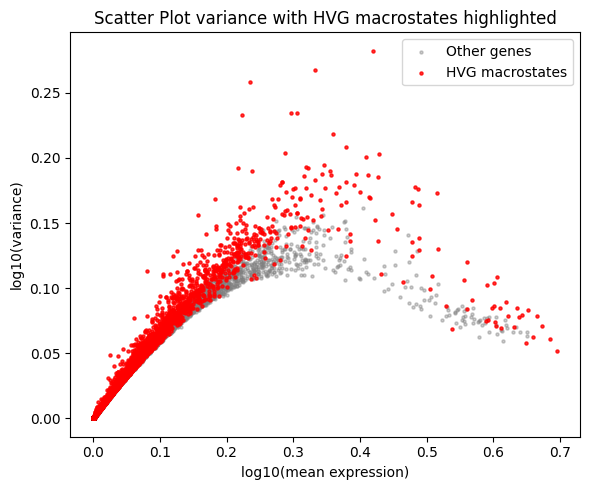

In [8]:
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# Mean and variance per gene
means = np.mean(X, axis=0)      # (n_genes,)
vars_  = np.var(X, axis=0)      # (n_genes,)

log_means = np.log10(means + 1)
log_vars  = np.log10(vars_ + 1)

all_genes = adata.var_names
hvg_mask = np.array([gene in all_hvg for gene in all_genes])

# Scatter plot mean–variance
plt.figure(figsize=(6, 5))
plt.scatter(
    log_means[~hvg_mask], log_vars[~hvg_mask],
    s=5, alpha=0.4, label="Other genes",
    c="gray")
plt.scatter(
    log_means[hvg_mask], log_vars[hvg_mask],
    s=5, alpha=0.8, label="HVG macrostates",
    c="red")
plt.xlabel("log10(mean expression)")
plt.ylabel("log10(variance)")
plt.title("Scatter Plot variance with HVG macrostates highlighted")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_directory}/scatterplot_macro.png", dpi=500, bbox_inches='tight')
plt.show()

Ratio variance inter and intra macrostates

In [9]:
print("Building global HVG matrix...")
all_hvg = list(all_hvg)
adata_hvg = adata[:, all_hvg].copy()

X = adata_hvg.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

valid_states = ['I1', 'I2', 'T1', 'T2', 'T3']
adata_hvg = adata_hvg[adata_hvg.obs['macrostates'].isin(valid_states)].copy()

labels = adata_hvg.obs['macrostates'].values
print("Compute intra variance...")
intra_var = []
for c in np.unique(labels):
    idx = np.where(labels == c)[0]
    if len(idx) > 1:
        intra_var.append(np.mean(np.var(X[idx, :], axis=0)))

intra_var_mean = np.mean(intra_var)
print("Compute inter variance...")
means_per_cluster = np.array([
    X[np.where(labels == c)[0], :].mean(axis=0)
    for c in np.unique(labels)
])

inter_var = np.mean(np.var(means_per_cluster, axis=0))
ratio = inter_var / intra_var_mean if intra_var_mean > 0 else np.nan

print(f"Inter/Intra macrostate ratio: {ratio:.4f}")

Building global HVG matrix...
Compute intra variance...
Compute inter variance...
Inter/Intra macrostate ratio: 0.0035


AMI (Ajusted Mutual Information)

In [13]:
resolutions = np.arange(0.1, 1, 0.1)
resolution = []
ami_tg_vals = [] # HVG per macrostates vs all genes 
ami_global_vals = [] # HVG per macrostates vs HVG global 
ami_hvg_vals = [] # HVG global vs all genes 
ari_tg_vals = [] # HVG per macrostates vs all genes 
ari_global_vals = [] # HVG per macrostates vs HVG global 
ari_hvg_vals = [] # HVG global vs all genes 
n_clust_tg = []
n_clust_macro = []
n_clust_global= []

# 1) PCA 
# Clustering based on all the genes
adata_tg = adata.copy()
sc.tl.pca(adata_tg, n_comps=20, use_highly_variable=False)
# Clustering based on the HVG per macrostates
all_genes = adata.var_names
hvg_mask_macro = np.array([gene in all_hvg for gene in all_genes])
adata_hvg_macro = adata[:, hvg_mask_macro].copy()
sc.tl.pca(adata_hvg_macro, n_comps=20, use_highly_variable=False)
# Clustering based on the HVG on the complete population (all cells) 
adata_hvg_global = adata.copy()
sc.pp.highly_variable_genes(adata_hvg_global,n_top_genes=2000,flavor="cell_ranger")
sc.tl.pca(adata_hvg_global, n_comps=20, use_highly_variable=True)

for res in resolutions:

    # Clustering TG (all the gene)
    sc.pp.neighbors(adata_tg, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(adata_tg, resolution=res, key_added="leiden_TG_tmp")
    y_tg = adata_tg.obs["leiden_TG_tmp"]

    # Clustering HVG macrostates
    sc.pp.neighbors(adata_hvg_macro, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(adata_hvg_macro, resolution=res, key_added="leiden_HVG_macro_tmp")
    y_macro = adata_hvg_macro.obs["leiden_HVG_macro_tmp"]

    # Clustering HVG all cells
    sc.pp.neighbors(adata_hvg_global, n_neighbors=15, n_pcs=20)
    sc.tl.leiden(adata_hvg_global, resolution=res, key_added="leiden_HVG_global_tmp")
    y_global = adata_hvg_global.obs["leiden_HVG_global_tmp"]

    # Clusters number
    n_clust_tg.append(len(np.unique(y_tg)))
    n_clust_macro.append(len(np.unique(y_macro)))
    n_clust_global.append(len(np.unique(y_global)))

    # ARI
    ari_tg = adjusted_rand_score(y_macro, y_tg)
    ari_global = adjusted_rand_score(y_macro, y_global)
    # AMI 
    ami_tg = adjusted_mutual_info_score(y_macro, y_tg)
    ami_global = adjusted_mutual_info_score(y_macro, y_global)
    ami_hvg = adjusted_mutual_info_score(y_tg, y_global)

    resolution.append(res)
    ari_tg_vals.append(ari_tg)
    ari_global_vals.append(ari_global)
    ami_tg_vals.append(ami_tg)
    ami_hvg_vals.append(ami_hvg)
    ami_global_vals.append(ami_global)

print("Minimum clusters number : ")
print(f"AMI (all genes)      : {min(n_clust_tg)}")
print(f"AMI (HVG macro)      : {min(n_clust_macro)}")
print(f"AMI (HVG)      : {min(n_clust_global)}")

print("Maximum clusters number : ")
print(f"AMI (all genes)      : {max(n_clust_tg)}")
print(f"AMI (HVG macro)      : {max(n_clust_macro)}")
print(f"AMI (HVG)      : {max(n_clust_global)}")

Minimum clusters number : 
AMI (all genes)      : 4
AMI (HVG macro)      : 4
AMI (HVG)      : 4
Maximum clusters number : 
AMI (all genes)      : 15
AMI (HVG macro)      : 14
AMI (HVG)      : 14


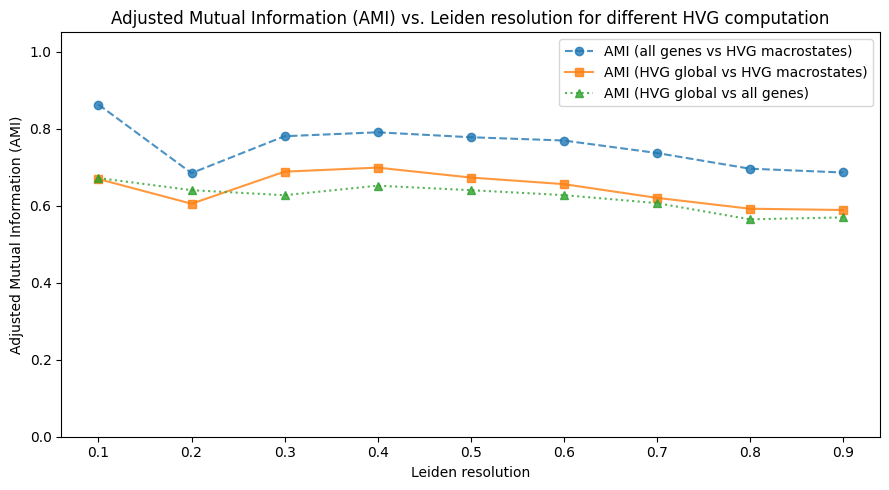

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# AMI (all genes vs HVG macrostates)
ax.plot(resolution, ami_tg_vals,"o--", label="AMI (all genes vs HVG macrostates)", alpha=0.8)
# AMI (HVG all cells vs HVG macrostates)
ax.plot(resolution, ami_global_vals,"s-", label="AMI (HVG global vs HVG macrostates)", alpha=0.8)
# AMI (HVG all cells vs HVG macrostates)
ax.plot(resolution, ami_hvg_vals,"^:", label="AMI (HVG global vs all genes)", alpha=0.8)

# Axis
ax.set_xlabel("Leiden resolution")
ax.set_ylabel("Adjusted Mutual Information (AMI)")
ax.set_ylim(0, 1.05)
#Title
ax.set_title("Adjusted Mutual Information (AMI) vs. Leiden resolution for different HVG computation")
# Legend
ax.legend()
# Save
plt.tight_layout()
plt.savefig(f"{output_directory}/ami_vs_n_clusters_3curves.png", dpi=300, bbox_inches="tight")
plt.show()

# 4) Evaluate the binarization

Look at pathways selected in the binarised matrix

Enrichment for 9

Top 2 pathways for 9:
  - Cilium Assembly (GO:0060271) (adj p=5.29e-07)
  - Cilium Organization (GO:0044782) (adj p=1.18e-06)
Enrichment for 8

Top 2 pathways for 8:
  - Regulation of Intracellular Signal Transduction (GO:1902531) (adj p=1.55e-05)
  - Intracellular Signaling Cassette (GO:0141124) (adj p=2.48e-04)
Enrichment for 0

Top 2 pathways for 0:
  - Cilium Assembly (GO:0060271) (adj p=1.82e-07)
  - Cilium Organization (GO:0044782) (adj p=1.18e-06)
Enrichment for 5

Top 2 pathways for 5:
  - Cilium Assembly (GO:0060271) (adj p=1.19e-05)
  - Plasma Membrane Bounded Cell Projection Assembly (GO:0120031) (adj p=3.62e-05)
Enrichment for 4

Top 2 pathways for 4:
  - Plasma Membrane Bounded Cell Projection Assembly (GO:0120031) (adj p=5.82e-06)
  - Cilium Assembly (GO:0060271) (adj p=5.82e-06)
Enrichment for 2

Top 2 pathways for 2:
  - Cellular Response to Cytokine Stimulus (GO:0071345) (adj p=3.55e-03)
  - Protein Transport (GO:0015031) (adj p=3.55e-03)


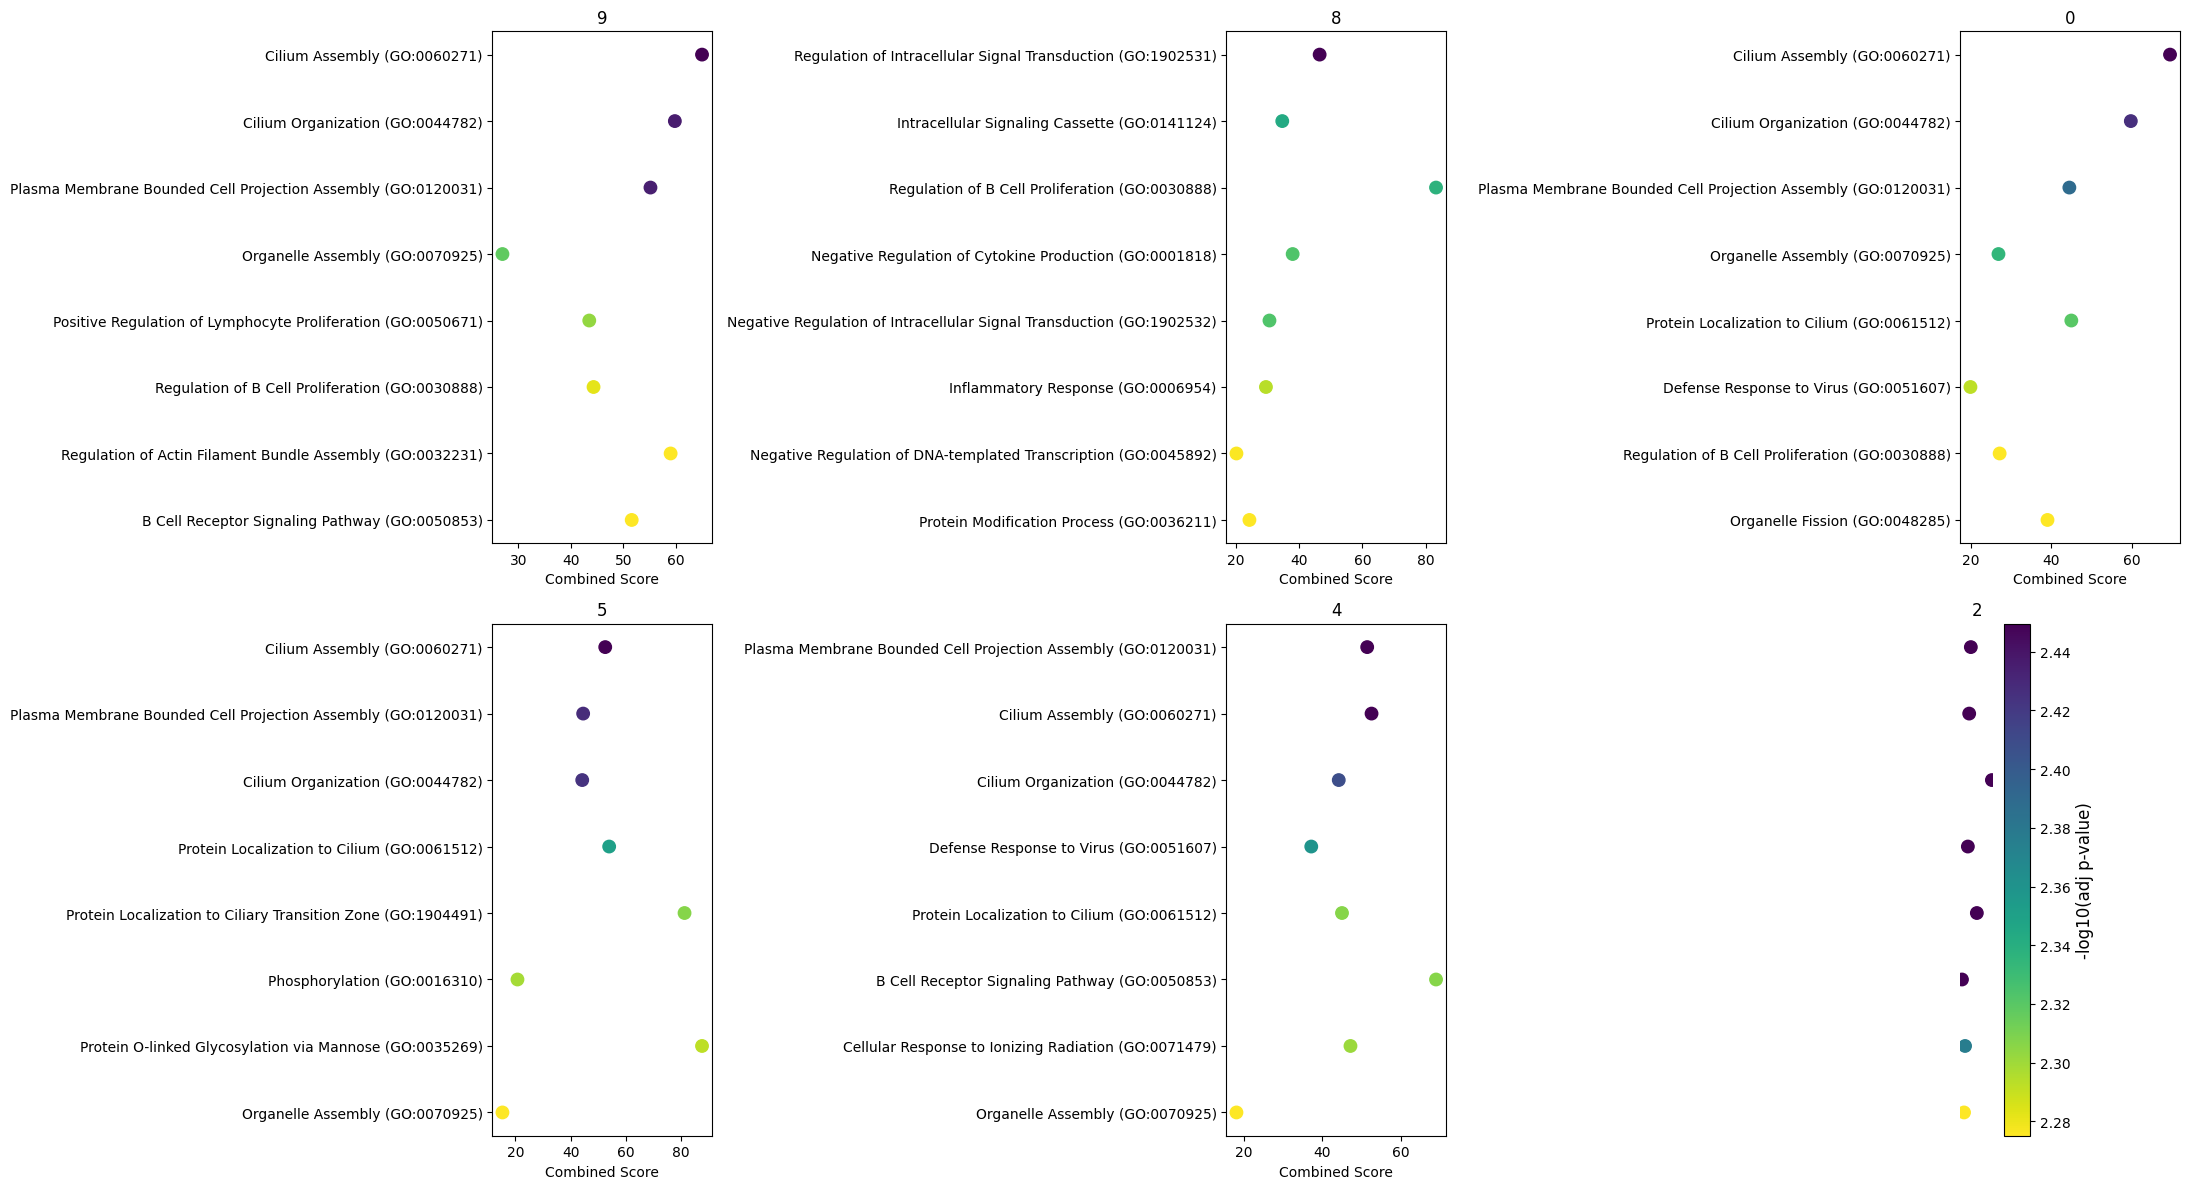

dict_keys(['Cilium Assembly', 'Cilium Organization', 'Regulation of Intracellular Signal Transduction', 'Intracellular Signaling Cassette', 'Plasma Membrane Bounded Cell Projection Assembly', 'Cellular Response to Cytokine Stimulus', 'Protein Transport'])


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
enrich_results = {}
top_terms_per_state = {}

for i, ct in enumerate(macrostates):
    print(f"Enrichment for {ct}")
    enr = gp.enrichr(
        gene_list=hvg_dict[ct],
        gene_sets="GO_Biological_Process_2026",
        organism="human",
        outdir=None)
    df = enr.results.copy()
    
    # Top pathways
    df_sorted = df.sort_values("Adjusted P-value")
    top2 = df_sorted.head(2)
    
    # ← Stocker les top termes
    top_terms_per_state[ct] = top2["Term"].tolist()
    
    print(f"\nTop 2 pathways for {ct}:")
    for _, row in top2.iterrows():
        print(f"  - {row['Term']} (adj p={row['Adjusted P-value']:.2e})")
    
    df = df.sort_values("Adjusted P-value").head(8)
    df["GeneRatio"] = df["Overlap"].str.split("/").apply(lambda x: int(x[0]) / int(x[1]))
    
    scp = axes[i].scatter(
        x=df["Combined Score"],
        y=df["Term"],
        c=-np.log10(df["Adjusted P-value"]),
        s=80, cmap="viridis_r")
    axes[i].set_title(ct)
    axes[i].set_xlabel("Combined Score")
    axes[i].set_ylabel("")
    axes[i].invert_yaxis()

cax = axes[-1]
cax.axis("off") 
cbar = fig.colorbar(scp, ax=cax, fraction=0.8)
cbar.set_label("-log10(adj p-value)", fontsize=12)
plt.subplots_adjust(wspace=0.5, hspace=0.4)
plt.tight_layout()
fig.savefig(f"{output_directory}/GO_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

pathways = {}
for ct, terms in top_terms_per_state.items():
    for term in terms:
        label = term.split(" (GO:")[0]
        pathways[label] = pathway[term]

print(pathways.keys())

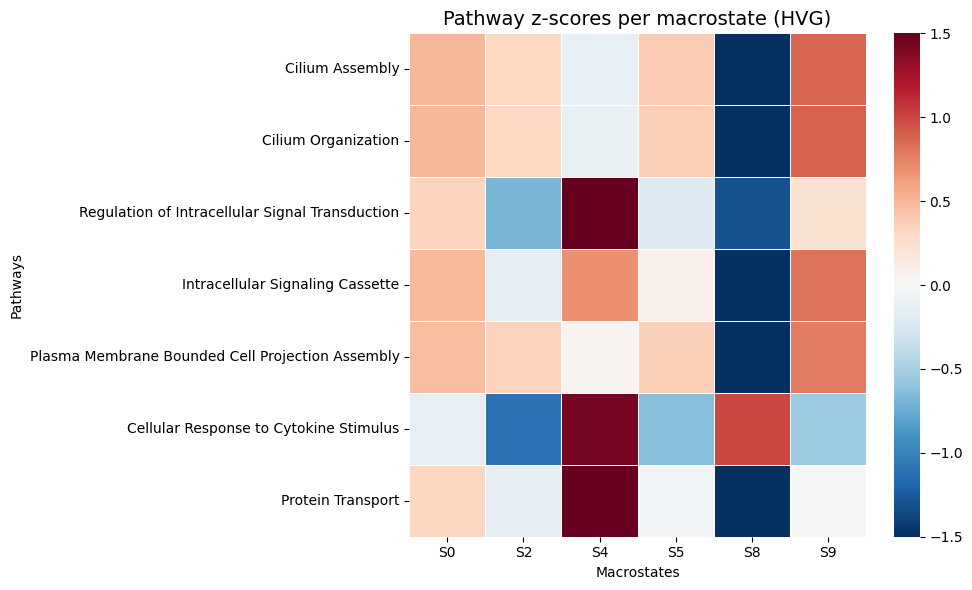

In [53]:
# Compute score for each cell for each pathway
for name, gene_list in pathways.items():
    gene_list_filtered = [g for g in gene_list if g in adata_no_none.var_names]
    if len(gene_list_filtered) == 0:
        print(f"No genes found for {name}")
        continue
    sc.tl.score_genes(adata_no_none, gene_list=gene_list_filtered, score_name=name)

scores = list(pathways.keys())
mean_scores = (
    adata_no_none.obs
    .groupby("macrostates")[scores]
    .mean())
mean_scores_z_all = mean_scores.apply(lambda x: (x - x.mean()) / x.std(), axis=0)

# Plot
plt.figure(figsize=(10, 6))

sns.heatmap(
    mean_scores_z_all.T,
    cmap="RdBu_r", center=0,
    linewidths=0.5,
    cbar=True,vmin=-1.5,
    vmax=1.5,
    yticklabels=True
)
plt.title("Pathway z-scores per macrostate (HVG)", fontsize=14)
plt.xlabel("Macrostates")
plt.ylabel("Pathways")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_combined_heatmap.png", dpi=300)
plt.show()

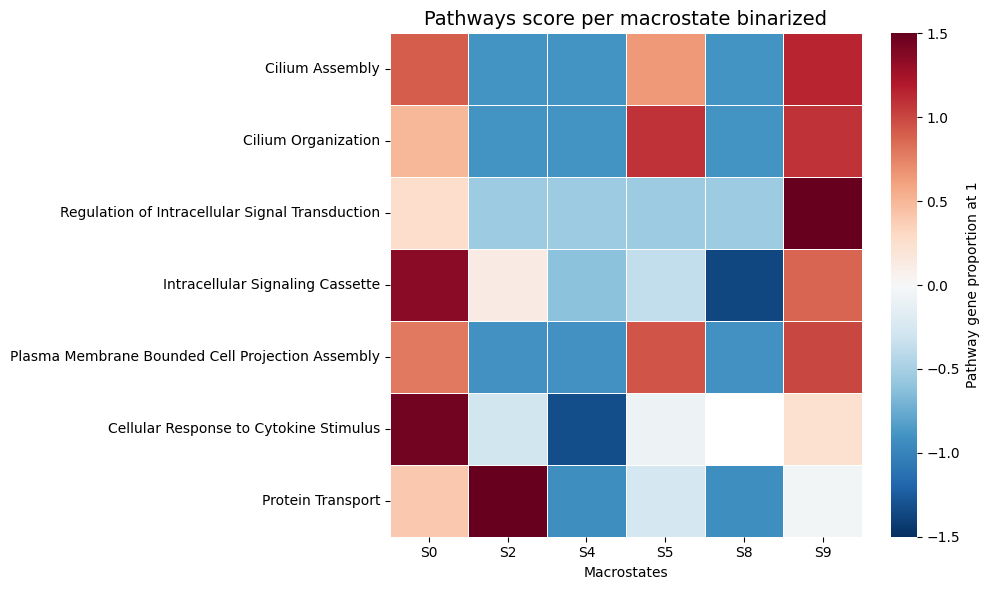

In [55]:
binary_matrix = pd.DataFrame.from_dict(binarized_states, orient="index").fillna(np.nan)

binary_matrix = binary_matrix.apply(pd.to_numeric, errors="coerce")

scores = {}

for name, genes in pathways.items():
    # keep genes only present in binary_matrix
    genes_present = [g for g in genes if g in binary_matrix.columns]
    if len(genes_present) == 0:
        # pathway empthy
        scores[name] = pd.Series(np.nan, index=binary_matrix.index, dtype=float)
        continue

    mat = binary_matrix.loc[:, genes_present]

    num = (mat == 1).sum(axis=1)          # number of genes activated (=1) per macrostates
    den = mat.notna().sum(axis=1)         # number of 0 or 1, not NA
    score = num / den                     # if den > 0, else NaN
    #score = num / len(genes_present)

    scores[name] = score
    

scores_df = pd.DataFrame(scores)
order = ["S0", "S2", "S4", "S5", "S8","S9"]
scores_df = scores_df.loc[order]
scores_df_z = scores_df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
scores_df_z = scores_df_z.T

#Plot 
plt.figure(figsize=(10, 6))
sns.heatmap(scores_df_z,cmap="RdBu_r",annot=False, linewidths=0.5, center=0,fmt=".2f",vmin=-1.5, vmax=1.5,cbar_kws={"label": "Pathway gene proportion at 1"})
plt.title("Pathways score per macrostate binarized", fontsize=14)
plt.xlabel("Macrostates")
plt.tight_layout()
plt.savefig(f"{output_directory}/pathways_macrostates_percent_binarized.png", dpi=300, bbox_inches="tight")
plt.show()